---

### Import Libraries

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error , r2_score

from sklearn.preprocessing import StandardScaler

### Clean up and understand

In [55]:
d = pd.read_csv('car_prices_homework.csv')
d.head(5)

,Age,Mileage,PreviousOwners,Price
0,3,30000.0,1.0,15000.0
1,5,70000.0,2.0,12000.0
2,2,20000.0,1.0,17000.0
3,8,120000.0,3.0,8000.0
4,4,50000.0,1.0,14000.0


In [56]:
d.shape

(31, 4)

In [57]:
d.isna().sum()

Age               0
Mileage           2
PreviousOwners    2
Price             2
dtype: int64

In [58]:
d.duplicated().sum()

np.int64(3)

In [59]:
d.fillna(d.mean(), inplace = True)
d.drop_duplicates(inplace = True)

In [60]:
d.duplicated().sum()

np.int64(0)

In [61]:
d.info()

<class 'pandas.DataFrame'>
Index: 28 entries, 0 to 29
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             28 non-null     int64  
 1   Mileage         28 non-null     float64
 2   PreviousOwners  28 non-null     float64
 3   Price           28 non-null     float64
dtypes: float64(3), int64(1)
memory usage: 1.1 KB


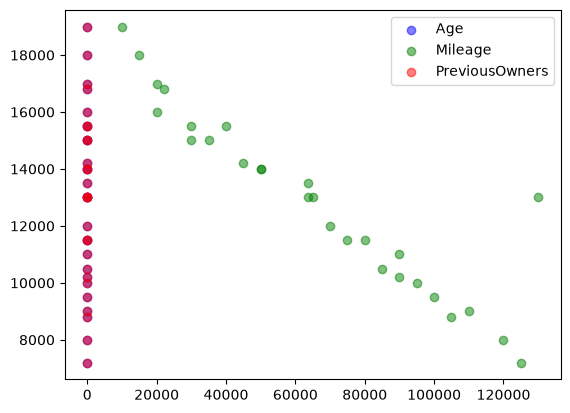

In [62]:
plt.scatter(d['Age'], d['Price'], color='blue', alpha=0.5)
plt.scatter(d['Mileage'], d['Price'], color='green', alpha = 0.5)
plt.scatter(d['PreviousOwners'], d['Price'], color='red', alpha=0.5)
plt.legend(['Age', 'Mileage', 'PreviousOwners'])
plt.show()

## Age & Previous owners direct relationship with eachother 

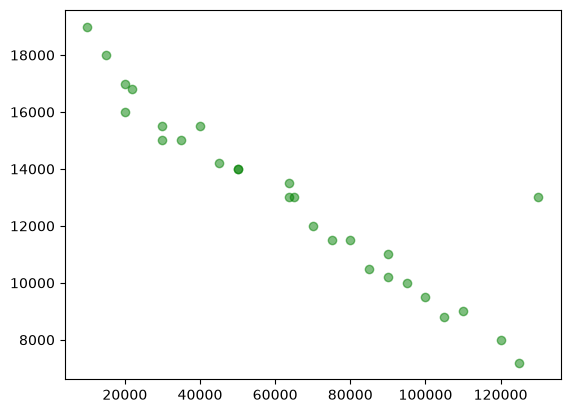

In [63]:
plt.scatter(d['Mileage'], d['Price'], color='green', alpha = 0.5)
plt.show()

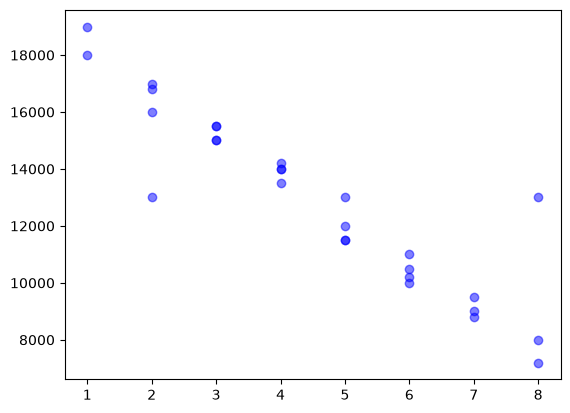

In [64]:
plt.scatter(d['Age'], d['Price'], color='blue', alpha=0.5)
plt.show()

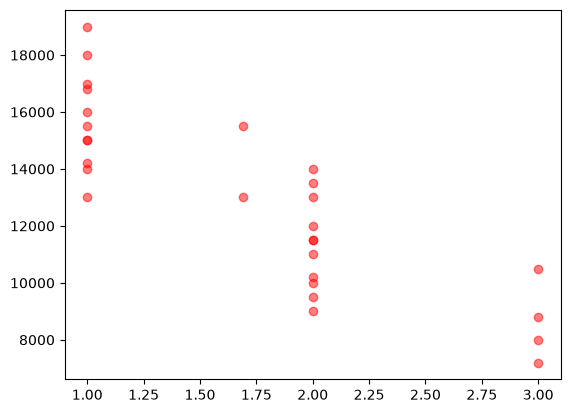

In [65]:
plt.scatter(d['PreviousOwners'], d['Price'], color='red', alpha=0.5)
plt.show()

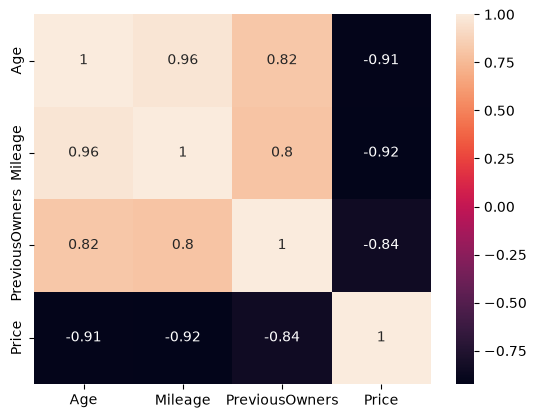

In [66]:
sns.heatmap(d.corr() , annot = True)
plt.show()

## Train & Eval

In [67]:
x = d[['Age' , 'Mileage' , 'PreviousOwners']]
y = d['Price']

In [68]:
x = d[['Mileage', 'PreviousOwners']] # test drop age

In [69]:
print(x)
print(y)

          Mileage  PreviousOwners
0    30000.000000        1.000000
1    70000.000000        2.000000
2    20000.000000        1.000000
3   120000.000000        3.000000
4    50000.000000        1.000000
5    90000.000000        2.000000
6   100000.000000        2.000000
7    15000.000000        1.000000
8    75000.000000        2.000000
9    40000.000000        1.689655
10   85000.000000        3.000000
11   63689.655172        1.000000
12   63689.655172        2.000000
13  110000.000000        2.000000
14   35000.000000        1.000000
15  130000.000000        1.689655
16   10000.000000        1.000000
18   22000.000000        1.000000
19   95000.000000        2.000000
20   80000.000000        2.000000
21   45000.000000        1.000000
22   30000.000000        1.000000
23  105000.000000        3.000000
24   90000.000000        2.000000
25   20000.000000        1.000000
26  125000.000000        3.000000
27   65000.000000        2.000000
29   50000.000000        2.000000
0     15000.00

In [70]:
x_train , x_test , y_train , y_test = train_test_split(x, y , test_size = 0.3 , random_state = 42)

In [71]:
print(x_train.head(5))

     Mileage  PreviousOwners
13  110000.0        2.000000
15  130000.0        1.689655
1    70000.0        2.000000
4    50000.0        1.000000
5    90000.0        2.000000


In [72]:
lr = LinearRegression()
lr.fit(x_train , y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[ -0.05,-1651.15]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['Mileage','PreviousOwners']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.938e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [73]:
pred = lr.predict(x_test)
print(y_test)
print(pred)


9     15500.000000
26     7200.000000
8     11500.000000
22    15500.000000
0     15000.000000
12    13500.000000
18    16800.000000
23     8800.000000
11    13024.137931
Name: Price, dtype: float64
[14422.84601347  7659.12747688 12016.24463506 16102.76546094
 16102.76546094 12628.35220055 16535.71959262  8741.51280609
 14279.5060357 ]


In [74]:
print(mean_squared_error(y_test , pred)) ## sqrt(625107) = 790.65 
print(r2_score(y_test , pred)) 

625107.6651985883
0.9335911413978822


### Equation

In [75]:
equation_parts = [f"y = {lr.intercept_:.2f}"]

for i in range(len(x.columns)):
    feature_name = x.columns[i]
    feature_coefficient = lr.coef_[i]
    equation_parts.append(f"+ {feature_coefficient:.2f} * {feature_name}")

#print(equation_parts)
print(' '.join(equation_parts))

y = 19377.50 + -0.05 * Mileage + -1651.15 * PreviousOwners


## Test scaling

In [76]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [77]:
lr.fit(x_train_sc , y_train)
pred = lr.predict(x_test_sc)

In [78]:
print(y_test)
print(pred)

9     15500.000000
26     7200.000000
8     11500.000000
22    15500.000000
0     15000.000000
12    13500.000000
18    16800.000000
23     8800.000000
11    13024.137931
Name: Price, dtype: float64
[14422.84601347  7659.12747688 12016.24463506 16102.76546094
 16102.76546094 12628.35220055 16535.71959262  8741.51280609
 14279.5060357 ]


In [79]:
import math
print(mean_squared_error(y_test , pred))
print(f"square root error: {math.sqrt(mean_squared_error(y_test , pred))} \n")

print(r2_score(y_test , pred))

625107.6651985891
square root error: 790.6375055602846 

0.9335911413978821
